In [1]:
# Module 2 configuration

import os

CLIP_EMBEDDING_DIR = "/kaggle/input/datasets/shubhamnitc/ucf-crime-test-split-clip-embeddings"
SEMANTIC_SPIKE_DIR = "/kaggle/working/ucf_crime_test_semantic_spikes"
SEGMENT_DIR = "/kaggle/working/ucf_crime_test_segments"

CONTEXT_WINDOW = 5
SPIKE_STD_FACTOR = 2.0
MIN_SPIKE_THRESHOLD = 0.05
MIN_SEGMENT_LENGTH = 5

os.makedirs(SEMANTIC_SPIKE_DIR, exist_ok=True)
os.makedirs(SEGMENT_DIR, exist_ok=True)

In [2]:
# Compute semantic spikes using rolling context (O(N))

import numpy as np

def compute_semantic_spikes(embeddings, k):

    n, d = embeddings.shape
    spikes = np.zeros(n, dtype=np.float32)

    running_sum = np.zeros(d, dtype=np.float32)

    for i in range(1, n):

        running_sum += embeddings[i-1]

        if i > k:
            running_sum -= embeddings[i-k-1]

        window = min(i, k)

        context = running_sum / window
        context = context / (np.linalg.norm(context) + 1e-8)

        cos_sim = np.dot(embeddings[i], context)

        spikes[i] = 1 - cos_sim

    return spikes

In [3]:
# Create segments from semantic spikes

import numpy as np

def create_segments(spikes, std_factor):

    mean = spikes.mean()
    std = spikes.std()

    threshold = max(mean + std_factor * std, MIN_SPIKE_THRESHOLD)

    segments = []

    start = 0
    current_beta = 0.0

    for i in range(1, len(spikes)):

        if spikes[i] > threshold and (i - start) >= MIN_SEGMENT_LENGTH:

            segments.append([start, i, current_beta])

            start = i
            current_beta = spikes[i]

    segments.append([start, len(spikes), current_beta])

    return np.array(segments), threshold

In [4]:
# Process dataset to compute semantic spikes per video

import os
import numpy as np
from tqdm import tqdm

embedding_files = sorted(
    f for f in os.listdir(CLIP_EMBEDDING_DIR) if f.endswith(".npy")
)

for fname in tqdm(embedding_files):

    in_path = os.path.join(CLIP_EMBEDDING_DIR, fname)
    out_path = os.path.join(SEMANTIC_SPIKE_DIR, fname)

    embeddings = np.load(in_path)

    spikes = compute_semantic_spikes(embeddings, CONTEXT_WINDOW)

    np.save(out_path, spikes)

100%|██████████| 290/290 [00:04<00:00, 60.19it/s]


In [5]:
# Process dataset to create segments from spikes

import os
import numpy as np
from tqdm import tqdm

spike_files = sorted(
    f for f in os.listdir(SEMANTIC_SPIKE_DIR) if f.endswith(".npy")
)

for fname in tqdm(spike_files):

    in_path = os.path.join(SEMANTIC_SPIKE_DIR, fname)
    out_path = os.path.join(SEGMENT_DIR, fname)

    spikes = np.load(in_path)

    segments, threshold = create_segments(spikes, SPIKE_STD_FACTOR)

    np.save(out_path, segments)

100%|██████████| 290/290 [00:00<00:00, 2474.00it/s]



Abuse028_x264.npy
mean: 0.029 std: 0.0426 threshold: 0.1142 max: 0.366

Abuse030_x264.npy
mean: 0.0316 std: 0.0185 threshold: 0.0686 max: 0.0918

Arrest001_x264.npy
mean: 0.0227 std: 0.0194 threshold: 0.0616 max: 0.1325

Arrest007_x264.npy
mean: 0.0599 std: 0.0788 threshold: 0.2175 max: 0.5892

Arrest024_x264.npy
mean: 0.0384 std: 0.0207 threshold: 0.0797 max: 0.14

Arrest030_x264.npy
mean: 0.0291 std: 0.0175 threshold: 0.0641 max: 0.1744

Arrest039_x264.npy
mean: 0.0419 std: 0.0362 threshold: 0.1144 max: 0.5097

Arson007_x264.npy
mean: 0.0097 std: 0.0175 threshold: 0.0447 max: 0.2393

Arson009_x264.npy
mean: 0.0417 std: 0.0309 threshold: 0.1034 max: 0.1276

Arson010_x264.npy
mean: 0.0591 std: 0.1158 threshold: 0.2907 max: 0.6691


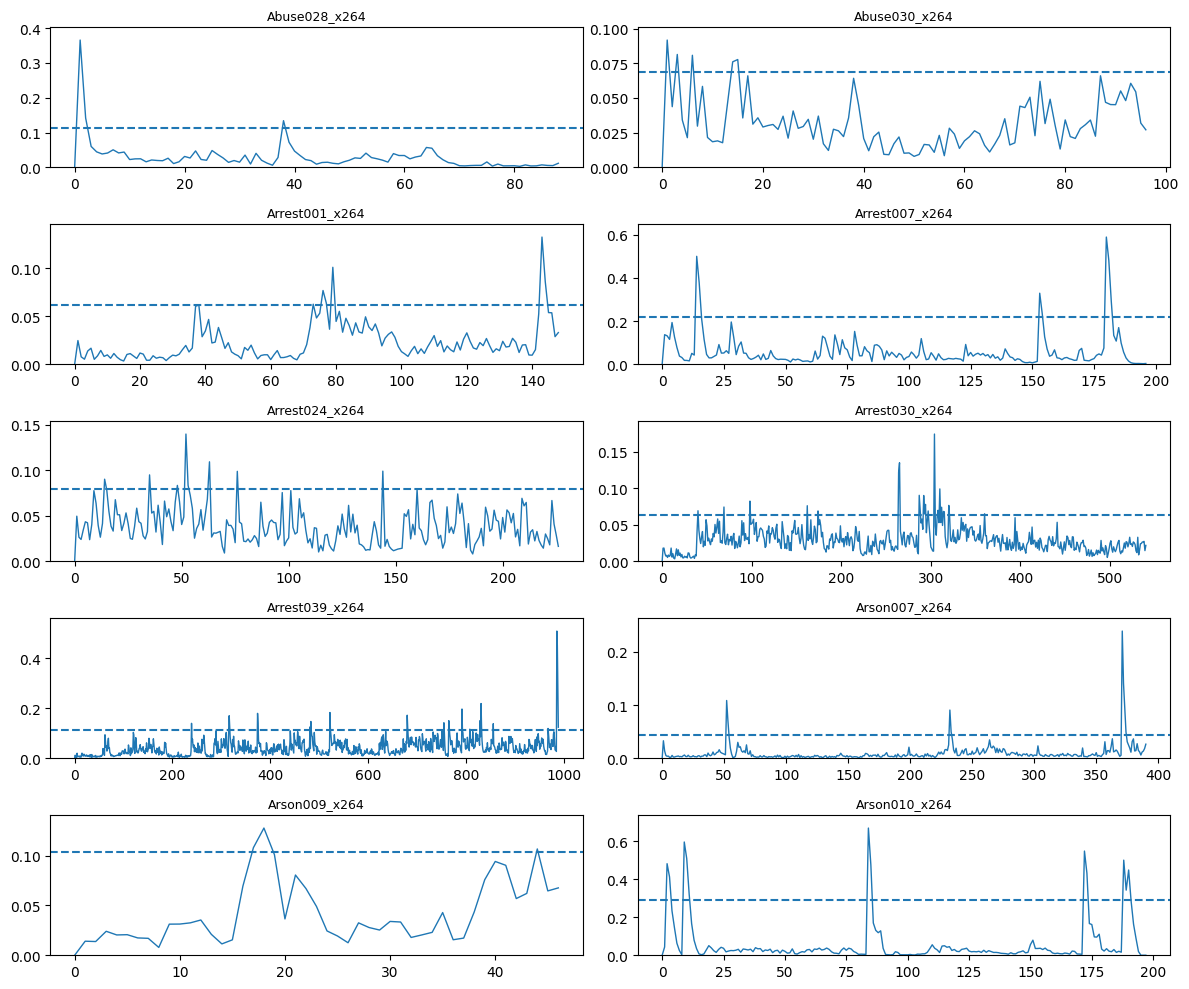

In [6]:
# Inspect spike distributions for multiple videos

import numpy as np
import os
import matplotlib.pyplot as plt

files = sorted(
    f for f in os.listdir(CLIP_EMBEDDING_DIR) if f.endswith(".npy")
)[:10]

rows = 5
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(12,10))
axes = axes.flatten()

for i, fname in enumerate(files):

    embeddings = np.load(os.path.join(CLIP_EMBEDDING_DIR, fname))
    spikes = compute_semantic_spikes(embeddings, CONTEXT_WINDOW)

    mean = spikes.mean()
    std = spikes.std()
    threshold = mean + 2 * std

    ax = axes[i]
    ax.plot(spikes, linewidth=1)
    ax.axhline(threshold, linestyle="--")
    ax.set_title(fname.replace(".npy",""), fontsize=9)
    ax.set_ylim(0, spikes.max()*1.1)

    print(f"\n{fname}")
    print("mean:", round(mean,4),
          "std:", round(std,4),
          "threshold:", round(threshold,4),
          "max:", round(spikes.max(),4))

plt.tight_layout()
plt.show()

In [7]:
# Compare thresholds for k = 2.0 and k = 1.5

import numpy as np
import os

files = sorted(
    f for f in os.listdir(CLIP_EMBEDDING_DIR) if f.endswith(".npy")
)[:10]

for fname in files:

    embeddings = np.load(os.path.join(CLIP_EMBEDDING_DIR, fname))
    spikes = compute_semantic_spikes(embeddings, CONTEXT_WINDOW)

    mean = spikes.mean()
    std = spikes.std()

    t2 = mean + 2.0 * std
    t15 = mean + 1.5 * std

    print(f"\n{fname}")
    print("mean:", round(mean,4),
          "std:", round(std,4))
    print("threshold 2σ :", round(t2,4))
    print("threshold 1.5σ:", round(t15,4))
    print("max spike:", round(spikes.max(),4))


Abuse028_x264.npy
mean: 0.029 std: 0.0426
threshold 2σ : 0.1142
threshold 1.5σ: 0.0929
max spike: 0.366

Abuse030_x264.npy
mean: 0.0316 std: 0.0185
threshold 2σ : 0.0686
threshold 1.5σ: 0.0594
max spike: 0.0918

Arrest001_x264.npy
mean: 0.0227 std: 0.0194
threshold 2σ : 0.0616
threshold 1.5σ: 0.0519
max spike: 0.1325

Arrest007_x264.npy
mean: 0.0599 std: 0.0788
threshold 2σ : 0.2175
threshold 1.5σ: 0.1781
max spike: 0.5892

Arrest024_x264.npy
mean: 0.0384 std: 0.0207
threshold 2σ : 0.0797
threshold 1.5σ: 0.0693
max spike: 0.14

Arrest030_x264.npy
mean: 0.0291 std: 0.0175
threshold 2σ : 0.0641
threshold 1.5σ: 0.0553
max spike: 0.1744

Arrest039_x264.npy
mean: 0.0419 std: 0.0362
threshold 2σ : 0.1144
threshold 1.5σ: 0.0963
max spike: 0.5097

Arson007_x264.npy
mean: 0.0097 std: 0.0175
threshold 2σ : 0.0447
threshold 1.5σ: 0.0359
max spike: 0.2393

Arson009_x264.npy
mean: 0.0417 std: 0.0309
threshold 2σ : 0.1034
threshold 1.5σ: 0.088
max spike: 0.1276

Arson010_x264.npy
mean: 0.0591 std: 

In [8]:
# Inspect segment counts across videos

import os
import numpy as np

segment_files = sorted(
    f for f in os.listdir(SEGMENT_DIR) if f.endswith(".npy")
)

counts = []

for fname in segment_files:

    segments = np.load(os.path.join(SEGMENT_DIR, fname))

    counts.append(len(segments))

print("Videos processed:", len(counts))
print("Min segments:", min(counts))
print("Max segments:", max(counts))
print("Mean segments:", round(np.mean(counts),2))
print("Median segments:", round(np.median(counts),2))

Videos processed: 290
Min segments: 1
Max segments: 201
Mean segments: 5.95
Median segments: 3.0



Normal_Videos_003_x264.npy
mean: 0.0222 std: 0.0152
threshold 2σ : 0.0526
threshold 1.5σ: 0.045
max spike: 0.0997

Normal_Videos_006_x264.npy
mean: 0.0174 std: 0.0067
threshold 2σ : 0.0309
threshold 1.5σ: 0.0275
max spike: 0.0331

Normal_Videos_010_x264.npy
mean: 0.0235 std: 0.0141
threshold 2σ : 0.0517
threshold 1.5σ: 0.0446
max spike: 0.0654

Normal_Videos_014_x264.npy
mean: 0.0205 std: 0.0224
threshold 2σ : 0.0654
threshold 1.5σ: 0.0542
max spike: 0.093

Normal_Videos_015_x264.npy
mean: 0.0181 std: 0.013
threshold 2σ : 0.0441
threshold 1.5σ: 0.0376
max spike: 0.0617

Normal_Videos_018_x264.npy
mean: 0.0041 std: 0.002
threshold 2σ : 0.0081
threshold 1.5σ: 0.0071
max spike: 0.0146

Normal_Videos_019_x264.npy
mean: 0.0209 std: 0.0165
threshold 2σ : 0.0538
threshold 1.5σ: 0.0456
max spike: 0.1066

Normal_Videos_024_x264.npy
mean: 0.0268 std: 0.0145
threshold 2σ : 0.0558
threshold 1.5σ: 0.0486
max spike: 0.0801

Normal_Videos_025_x264.npy
mean: 0.0064 std: 0.0028
threshold 2σ : 0.012
th

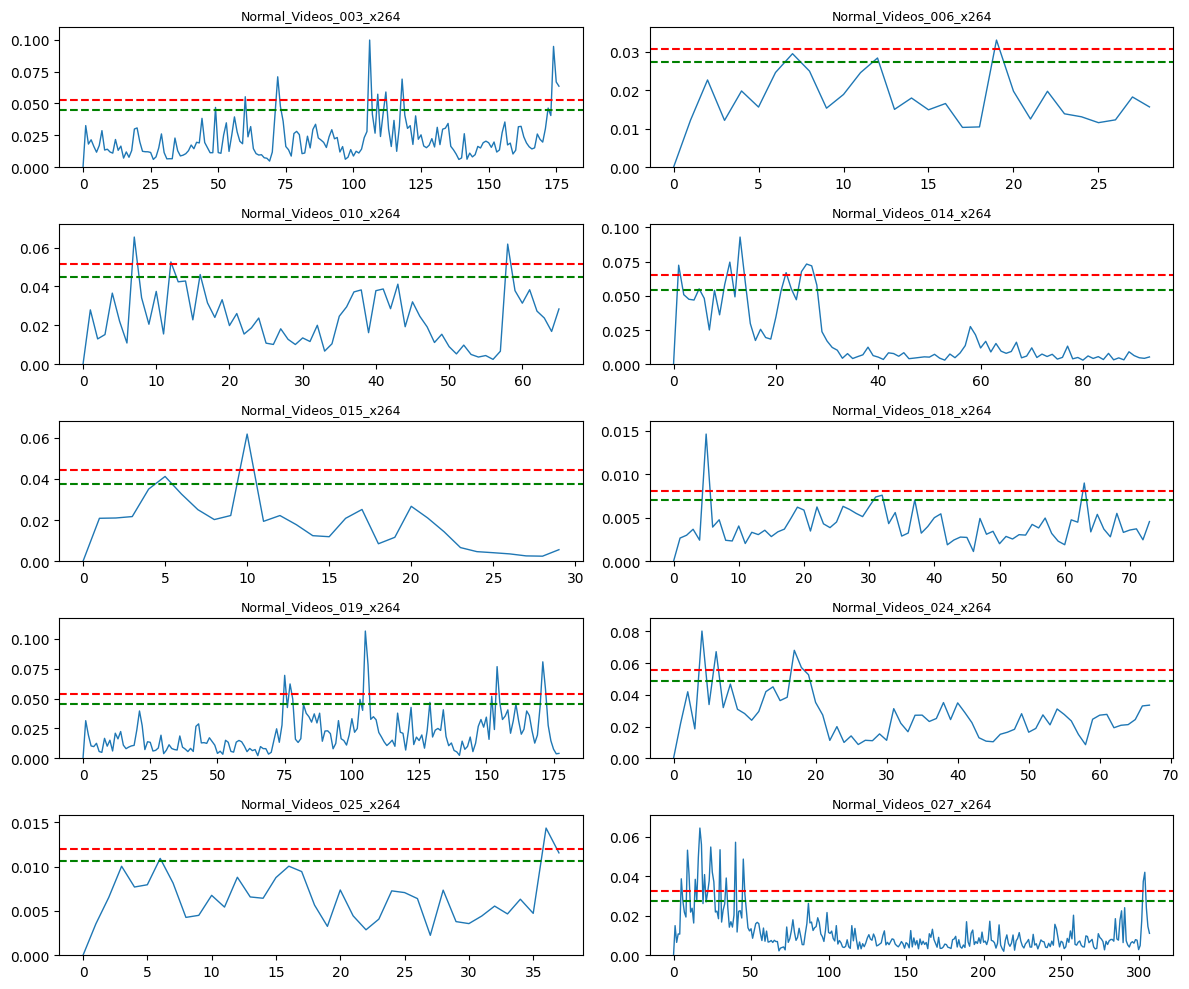

In [9]:
# Inspect spike signal for normal videos with both thresholds

import numpy as np
import os
import matplotlib.pyplot as plt

files = sorted(
    f for f in os.listdir(CLIP_EMBEDDING_DIR)
    if f.startswith("Normal") and f.endswith(".npy")
)[:10]

rows = 5
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(12,10))
axes = axes.flatten()

for i, fname in enumerate(files):

    embeddings = np.load(os.path.join(CLIP_EMBEDDING_DIR, fname))
    spikes = compute_semantic_spikes(embeddings, CONTEXT_WINDOW)

    mean = spikes.mean()
    std = spikes.std()

    t2 = mean + 2.0 * std
    t15 = mean + 1.5 * std

    ax = axes[i]
    ax.plot(spikes, linewidth=1)

    ax.axhline(t2, linestyle="--", color="red", label="2σ")
    ax.axhline(t15, linestyle="--", color="green", label="1.5σ")

    ax.set_title(fname.replace(".npy",""), fontsize=9)
    ax.set_ylim(0, spikes.max()*1.1)

    print(f"\n{fname}")
    print("mean:", round(mean,4),
          "std:", round(std,4))
    print("threshold 2σ :", round(t2,4))
    print("threshold 1.5σ:", round(t15,4))
    print("max spike:", round(spikes.max(),4))

plt.tight_layout()
plt.show()

In [10]:
# Find videos with very large segment counts

for fname in segment_files:

    segments = np.load(os.path.join(SEGMENT_DIR, fname))

    if len(segments) > 100:
        print(fname, len(segments))

Normal_Videos_924_x264.npy 114
Normal_Videos_935_x264.npy 201
